# MODELING

For xG modeling, the best models are once that progressively answer “How much predictive power comes from nonlinear interactions beyond classical geometry?”

As such, I will focus on 5 models, namely: 
Logistic Regression, Random Forest(for a Nonlinear baseline), XGBoost(for a Strong tabular benchmark), CatBoost(Categorical-feature benchmark), and a simple CNN.

These models will only take the core features for baseline xG: the distance from the goal, the angle of the shot relative to the open goal, the body part used as well as the type of shot.

In [1]:
import pandas as pd

df = pd.read_csv('~/Desktop/Football_Stats/xG/datasets/processed/Big5_shots.csv')
df.head()

,location,player,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,team,under_pressure,shot_open_goal,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,Arsenal,0,0,...,0,0,0,0,1,0,94.5,42.9,25.664372,17.611035
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,Chelsea,1,0,...,0,0,0,0,1,0,93.5,48.4,27.799460,15.648789
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,Arsenal,1,0,...,0,0,0,0,1,0,89.8,22.3,35.004714,11.297814
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,Chelsea,0,0,...,0,0,0,0,1,0,98.2,26.0,25.908300,14.904419
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,Arsenal,0,0,...,0,0,0,0,1,0,105.7,24.2,21.310326,14.633756


In [2]:
df.columns

Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_first_time', 'shot_statsbomb_xg', 'team', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'goalkeeper_success_out',
       'half_end_early_video_end', 'goal', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty', 'x', 'y', 'distance', 'angle'],
      dtype='object')

In [3]:
y = df['goal']
X = df.drop(['player', 'player_id', 'position', 'goal', 'shot_statsbomb_xg', 'shot_aerial_won', 'shot_first_time',
             'under_pressure', 'shot_open_goal', 'shot_follows_dribble', 'goalkeeper_success_out','half_end_early_video_end',
             'shot_technique_Backheel', 'shot_technique_Diving Header', 'shot_technique_Half Volley','shot_technique_Lob', 
             'shot_technique_Normal', 'shot_technique_Overhead Kick', 'shot_technique_Volley', 'shot_body_part_Head', 
             'shot_body_part_Left Foot', 'shot_body_part_Other', 'shot_body_part_Right Foot', 'team'], axis=1)

print(f"{X.shape}, {y.shape}")

(38728, 9), (38728,)


In [4]:
from sklearn.preprocessing import MinMaxScaler # Or StandardScaler

cols_to_normalize = ['distance', 'angle']

scaler = MinMaxScaler()
X[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

X.head()

,location,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[94.5, 42.9]",0,0,1,0,94.5,42.9,0.370154,0.097839
1,"[93.5, 48.4]",0,0,1,0,93.5,48.4,0.401726,0.086938
2,"[89.8, 22.3]",0,0,1,0,89.8,22.3,0.508272,0.062766
3,"[98.2, 26.0]",0,0,1,0,98.2,26.0,0.373761,0.082802
4,"[105.7, 24.2]",0,0,1,0,105.7,24.2,0.305770,0.081299


Run the following code if you don't have scikit-learn installed in your environment

In [5]:
# %conda install -c conda-forge scikit-learn

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,location,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
24269,"[109.4, 54.5]",0,0,1,0,109.4,54.5,0.256247,0.085889
23256,"[102.6, 23.7]",0,0,1,0,102.6,23.7,0.343209,0.078569
32636,"[107.6, 46.7]",0,0,1,0,107.6,46.7,0.199065,0.158373
7013,"[112.0, 31.2]",0,0,1,0,112.0,31.2,0.166511,0.150171
22862,"[110.7, 31.3]",0,0,1,0,110.7,31.3,0.178964,0.149857


In [7]:
X_train.drop(['location','x','y'], axis=1, inplace=True)
cordinates = X_test[['x', 'y']] # for model visualizations
X_test.drop(['location','x','y'], axis=1, inplace=True)

X_train.head()

,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle
24269,0,0,1,0,0.256247,0.085889
23256,0,0,1,0,0.343209,0.078569
32636,0,0,1,0,0.199065,0.158373
7013,0,0,1,0,0.166511,0.150171
22862,0,0,1,0,0.178964,0.149857


In [8]:
cordinates.shape

(11619, 2)

# MODELING

## LOGISTIC REGRESSION

In [9]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
goal_log = logistic_regressor.predict(X_test)
y_log= logistic_regressor.predict_proba(X_test)[:,1]
y_log[:10]

array([0.06504557, 0.16108573, 0.05076887, 0.01978805, 0.07100278,
       0.07737942, 0.04946869, 0.03557684, 0.05727612, 0.04853553])

In [11]:
log_df = X_test.copy()
log_df['xG'] = y_log
log_df.iloc[830]

shot_type_Corner       0.000000
shot_type_Free Kick    0.000000
shot_type_Open Play    1.000000
shot_type_Penalty      0.000000
distance               0.259537
angle                  0.097214
xG                     0.062683
Name: 8194, dtype: float64

In [12]:
log_df.iloc[100]

shot_type_Corner       0.000000
shot_type_Free Kick    0.000000
shot_type_Open Play    1.000000
shot_type_Penalty      0.000000
distance               0.111660
angle                  0.262675
xG                     0.224020
Name: 27031, dtype: float64

In [13]:
import joblib

joblib.dump(logistic_regressor, '/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/logistic_regressor.pkl')

['/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/logistic_regressor.pkl']

## RANDOM FOREST

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
goal_rf = random_forest.predict(X_test)
y_rf = random_forest.predict_proba(X_test)[:,1]
y_rf[:10]

array([0.04595732, 0.13376859, 0.04297054, 0.01921906, 0.05465514,
       0.09115425, 0.05190879, 0.03224866, 0.04087554, 0.0256698 ])

In [16]:
rf_df = pd.DataFrame()
rf_df['Goal'] = y_test.copy()
rf_df['xG'] = y_rf
rf_df.iloc[830]

Goal    0.000000
xG      0.095465
Name: 8194, dtype: float64

In [17]:
rf_df.iloc[100]

Goal    0.000000
xG      0.195574
Name: 27031, dtype: float64

In [18]:
joblib.dump(random_forest, '/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/random_forest.pkl')

['/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/random_forest.pkl']

## XGBOOST

Run the following code if you don't have xgboost installed in your environment

In [19]:
# % conda install -c conda-forge xgboost

In [20]:
import xgboost as xgb

In [21]:
xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
goal_xgb = xgb.predict(X_test)
y_xgb = xgb.predict_proba(X_test)[:,1]

In [23]:
xgb_df = pd.DataFrame()
xgb_df['Goal'] = y_test.copy()
xgb_df['xG'] = y_rf
xgb_df.iloc[830]

Goal    0.000000
xG      0.095465
Name: 8194, dtype: float64

In [24]:
xgb_df.iloc[100]

Goal    0.000000
xG      0.195574
Name: 27031, dtype: float64

In [25]:
joblib.dump(xgb, '/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/XGBoost.pkl')

['/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/XGBoost.pkl']

## CATBOOST

Run the following code if you don't have CatBoost installed in your environment

In [26]:
# %conda install -c conda-forge catboost

In [27]:
from catboost import CatBoostClassifier

In [28]:
catBoost = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=10
)

catBoost.fit(X_train, y_train)

0:	learn: 0.6293101	total: 64.6ms	remaining: 6.39s
10:	learn: 0.3549754	total: 83.9ms	remaining: 679ms
20:	learn: 0.2935872	total: 101ms	remaining: 381ms
30:	learn: 0.2790648	total: 119ms	remaining: 265ms
40:	learn: 0.2754185	total: 137ms	remaining: 197ms
50:	learn: 0.2742595	total: 155ms	remaining: 149ms
60:	learn: 0.2737097	total: 175ms	remaining: 112ms
70:	learn: 0.2733180	total: 193ms	remaining: 79ms
80:	learn: 0.2730474	total: 210ms	remaining: 49.2ms
90:	learn: 0.2728393	total: 227ms	remaining: 22.5ms
99:	learn: 0.2725484	total: 245ms	remaining: 0us


In [29]:
goal_cat = catBoost.predict(X_test)
y_cat = catBoost.predict_proba(X_test)[:,1]

In [30]:
cat_df = pd.DataFrame()
cat_df['Goal'] = y_test.copy()
cat_df['xG'] = y_cat
cat_df.iloc[830]

Goal    0.000000
xG      0.072163
Name: 8194, dtype: float64

In [31]:
cat_df.iloc[10]

Goal    0.000000
xG      0.075986
Name: 15912, dtype: float64

In [32]:
joblib.dump(catBoost, '/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/catBoost.pkl')

['/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/catBoost.pkl']

Foundation Model: TabPFN

In [33]:
# %conda install -c conda-forge tabpfn 
# %conda install -c conda-forge tabpfn-client
# %pip install tabpfn-client

or use mine: "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [34]:
# import os

# os.environ["TABPFN_TOKEN"] = "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [35]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token("tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs")
tabPFN = TabPFNClassifier()
tabPFN.fit(X_train, y_train)
goal_tabPFN = tabPFN.predict(X_test)
y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

00:00 Fitting... /

The provided train set hashes match previously uploaded train sets.


00:02 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:04 Predicting... Done!
00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:04 Predicting... Done!


In [36]:
y_tabPFN = tabPFN.predict_proba(X_test)[:,1]
goal_tab = logistic_regressor.predict(X_test)

00:00 Predicting... -

00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:08 Predicting... Done!


In [37]:
tab_df = pd.DataFrame()
tab_df['Goal'] = y_test.copy()
tab_df['xG'] = y_tabPFN

In [38]:
joblib.dump(tabPFN, '/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/TabPFN.pkl')

['/Users/nanakwamekankam/Desktop/Football_Stats/xG/models/Baseline Models/TabPFN.pkl']

# MODEL EVAULATION

For Logistic Regression

In [39]:
log_df.sort_values(by='xG', ascending=False).head()

,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,xG
28695,0,0,1,0,0.045361,1.000000,0.899175
23422,0,0,1,0,0.000000,0.904985,0.883580
28073,0,0,1,0,0.020590,0.859994,0.849577
2767,0,0,1,0,0.007508,0.828298,0.841148
2007,0,0,1,0,0.016809,0.796000,0.815057


In [40]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

print(f"Accuracy: {accuracy_score(y_test, goal_log)}:.3f\nLog Loss: {log_loss(y_test, y_log):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_log):.3f}\nBrier Score: {brier_score_loss(y_test, y_log):.3f}")

Accuracy: 0.9053274808503313:.3f
Log Loss: 0.286
ROC_AUC Score: 0.759
Brier Score: 0.081


For Random Forest

In [41]:
print(f"Accuracy: {accuracy_score(y_test, goal_rf)}:.3f\nLog Loss: {log_loss(y_test, y_rf):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_rf):.3f}\nBrier Score: {brier_score_loss(y_test, y_rf):.3f}")

Accuracy: 0.9048110852913331:.3f
Log Loss: 0.285
ROC_AUC Score: 0.761
Brier Score: 0.081


For XGBoost

In [42]:
print(f"Accuracy: {accuracy_score(y_test, goal_xgb)}:.3f\nLog Loss: {log_loss(y_test, y_xgb):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_xgb):.3f}\nBrier Score: {brier_score_loss(y_test, y_xgb):.3f}")

Accuracy: 0.9047250193648335:.3f
Log Loss: 0.284
ROC_AUC Score: 0.761
Brier Score: 0.081


For CatBoost

In [43]:
print(f"Accuracy: {accuracy_score(y_test, goal_cat)}:.3f\nLog Loss: {log_loss(y_test, y_cat):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_cat):.3f}\nBrier Score: {brier_score_loss(y_test, y_cat):.3f}")

Accuracy: 0.9048971512178329:.3f
Log Loss: 0.284
ROC_AUC Score: 0.761
Brier Score: 0.081


TabPFN

In [44]:
# print(f"Accuracy: {accuracy_score(y_test, goal_tabPFN):.3f}\nLog Loss: {log_loss(y_test, y_tabPFN):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_tabPFN):.3f}\nBrier Score: {brier_score_loss(y_test, y_tabPFN):.3f}")
print(f"Accuracy: {accuracy_score(y_test, goal_tab)}:.3f\nLog Loss: {log_loss(y_test, y_tabPFN):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_tabPFN):.3f}\nBrier Score: {brier_score_loss(y_test, y_tabPFN):.3f}")

Accuracy: 0.9053274808503313:.3f
Log Loss: 0.287
ROC_AUC Score: 0.762
Brier Score: 0.081


Calibration Curve

In [45]:
# %conda install -c conda-forge matplotlib

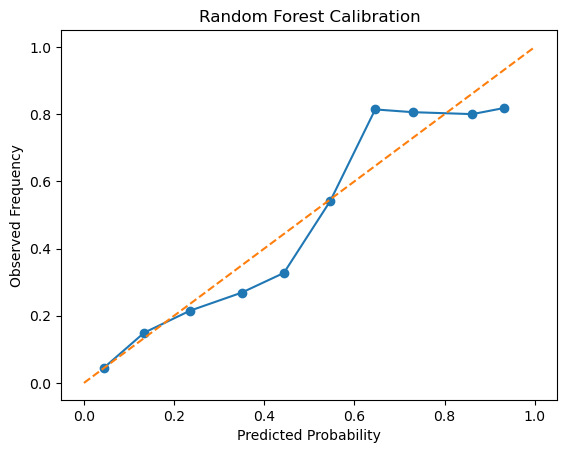

In [46]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_rf, prob_pred = calibration_curve(
    y_test,
    y_rf,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Random Forest Calibration")
plt.show()

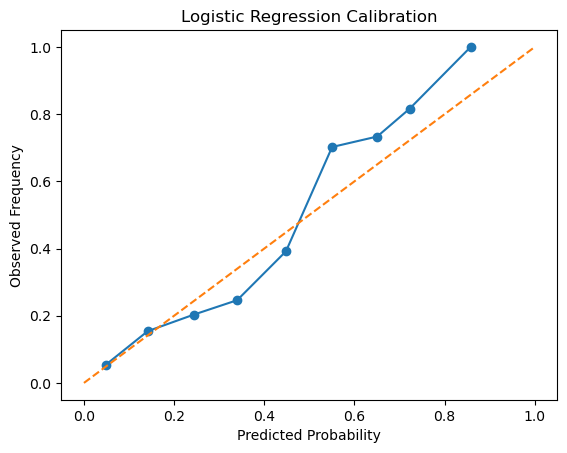

In [47]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_log,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Logistic Regression Calibration")
plt.show()

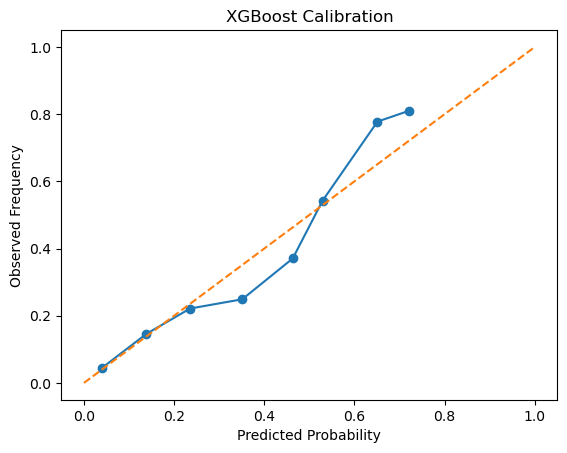

In [48]:
prob_xgb, prob_pred = calibration_curve(
    y_test,
    y_xgb,
    n_bins=10
)

plt.plot(prob_pred, prob_xgb, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("XGBoost Calibration")
plt.show()

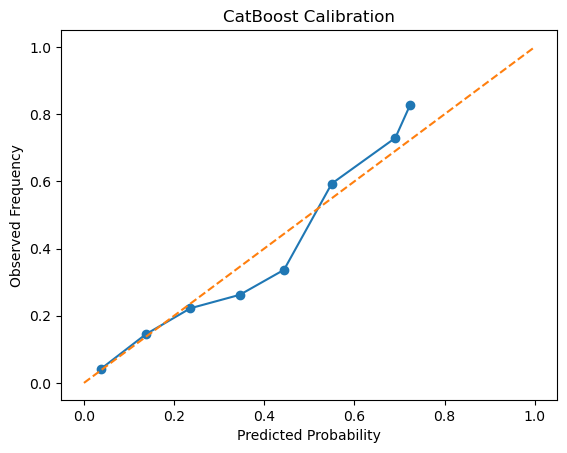

In [49]:
prob_cat, prob_pred = calibration_curve(
    y_test,
    y_cat,
    n_bins=10
)

plt.plot(prob_pred, prob_cat, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("CatBoost Calibration")
plt.show()

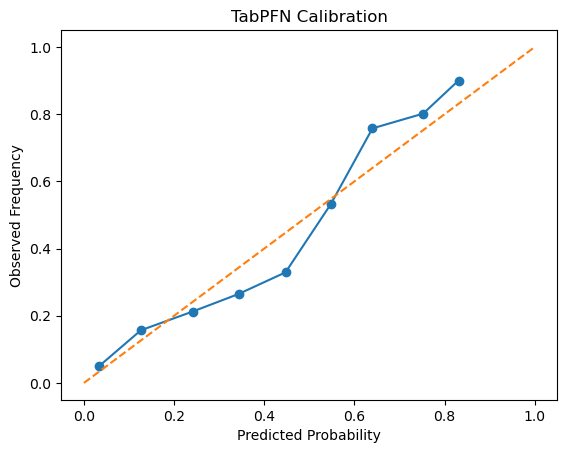

In [50]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_tabPFN,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("TabPFN Calibration")
plt.show()

## Feature Importance

In [51]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

angle                  0.409110
distance               0.390053
shot_type_Penalty      0.131953
shot_type_Open Play    0.062553
shot_type_Free Kick    0.006331
shot_type_Corner       0.000000
dtype: float64


# MODEL VISUALIZATIONS

In [52]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', linewidth=1)
colors = ['red', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors)
sc = pitch.scatter

In [53]:
# import numpy as np

# dataframes = {
#     'Logistic Regression': log_df,
#     'Random Forest': rf_df,
#     'XGBoost': xgb_df,
#     'CatBoost': cat_df
# }

# for name, df in dataframes.items():

#     fig, ax = pitch.draw(figsize=(10,8))
#     sc = pitch.scatter(
#         cordinates['x'], cordinates['y'], c=df['xG'],
#         cmap=cmap, edgecolors='black', linewidth=0.5, s=100, ax=ax
#     )

#     cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
#     cbar.set_label(f'{name} xG Probability')

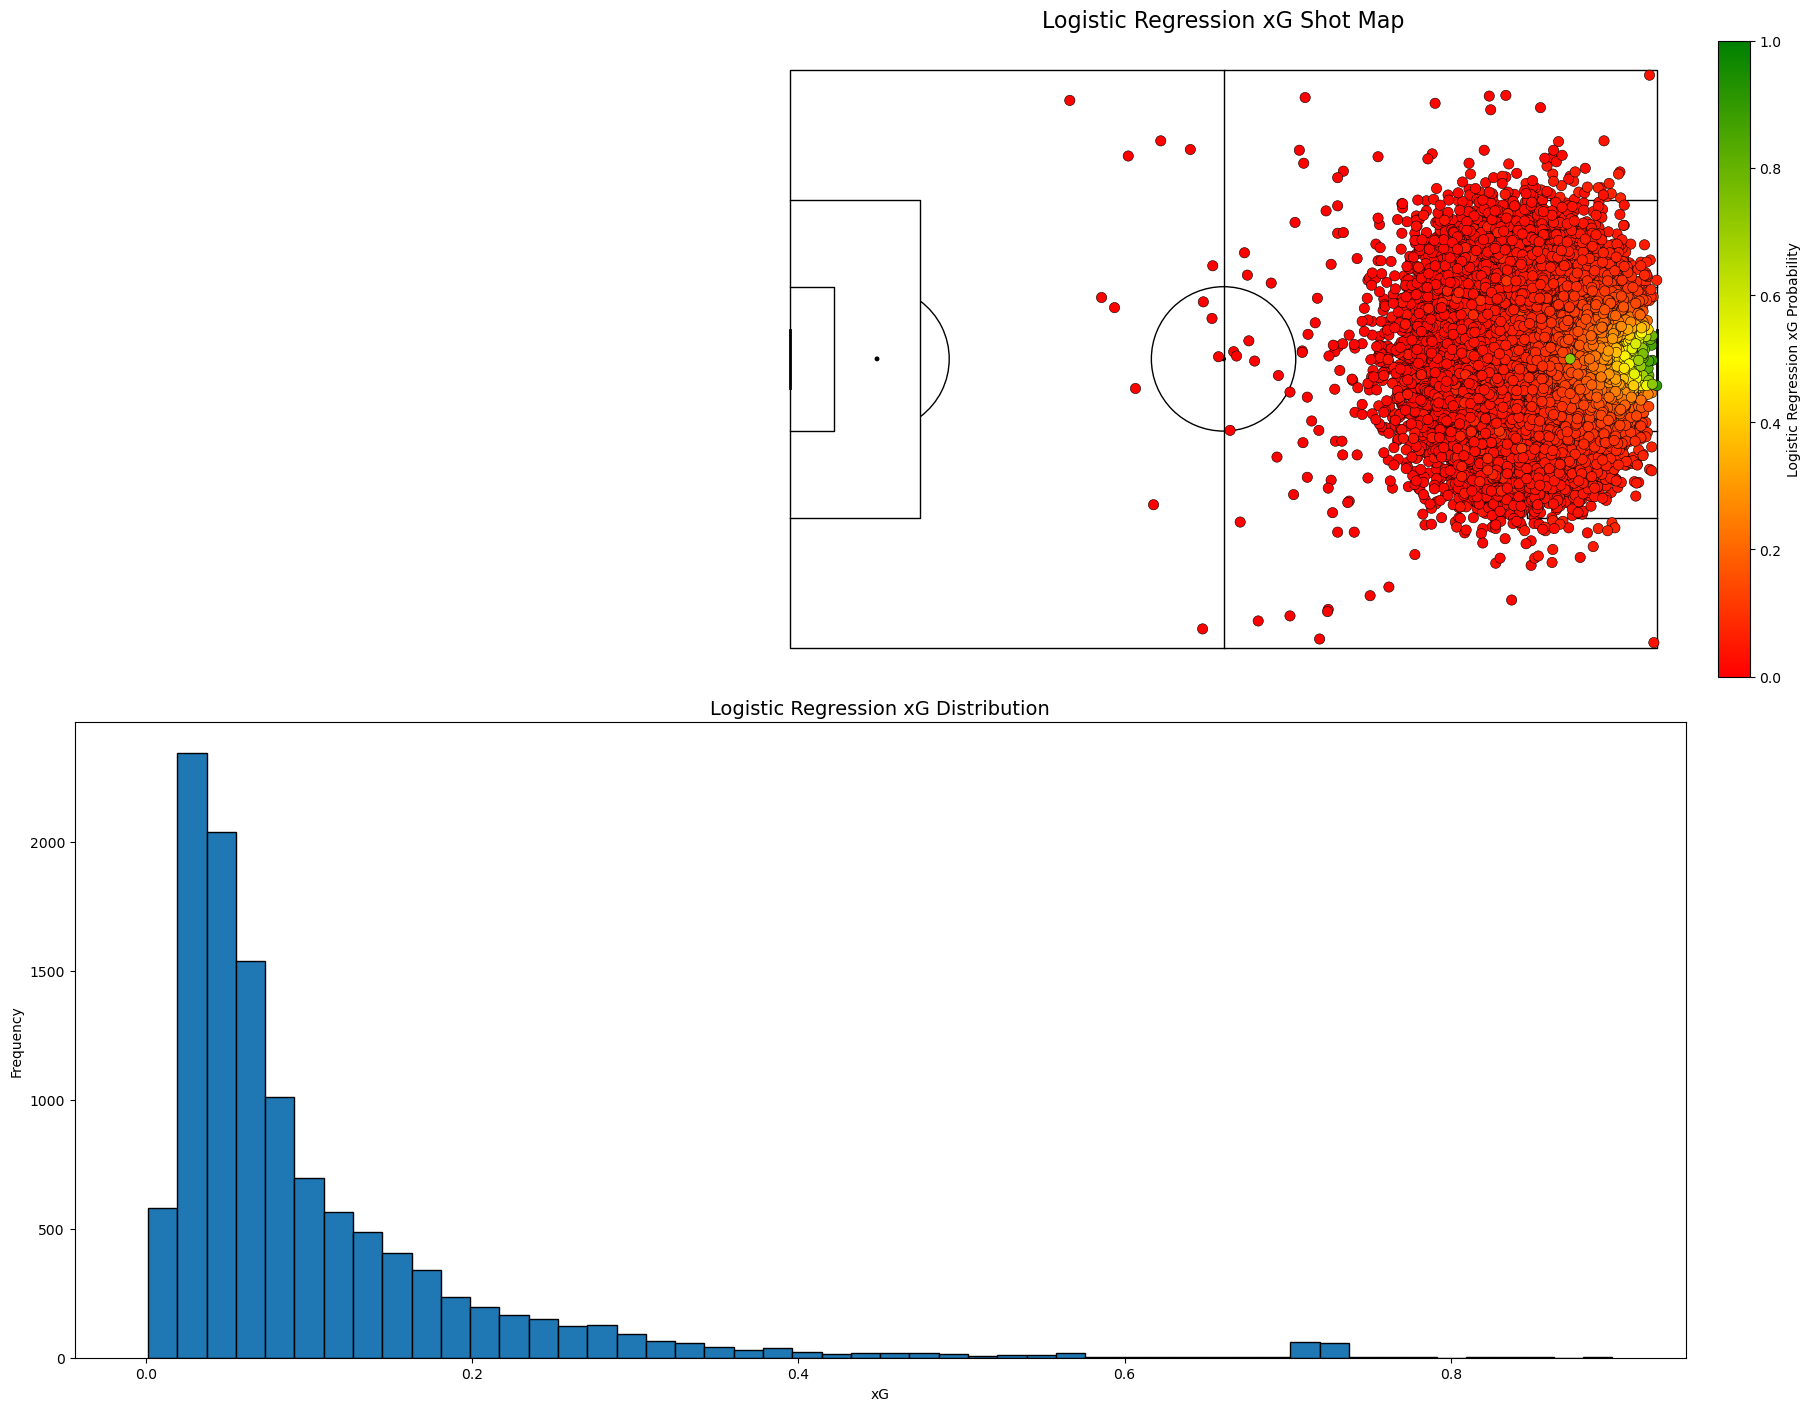

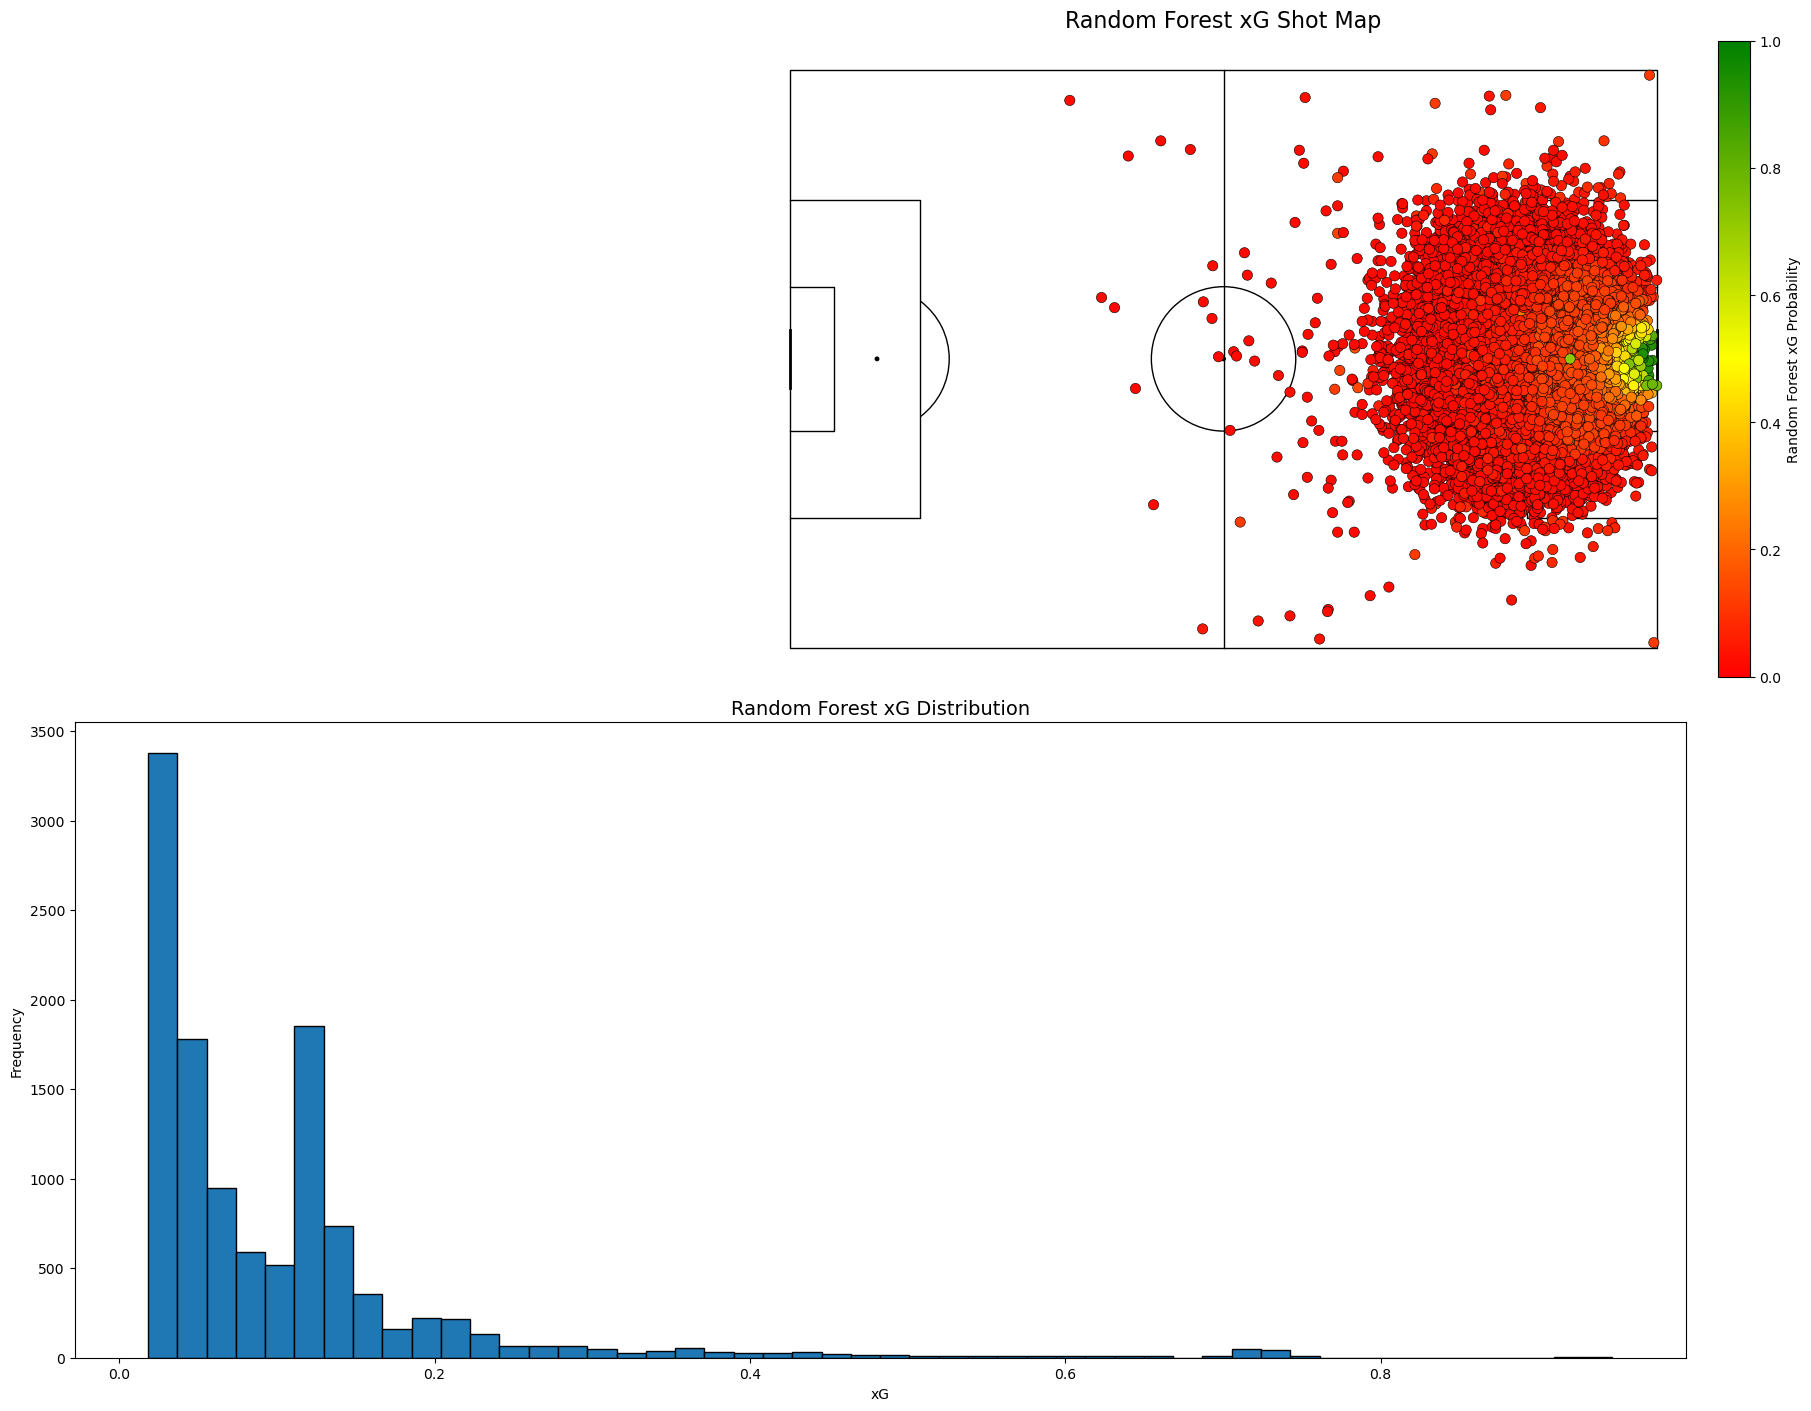

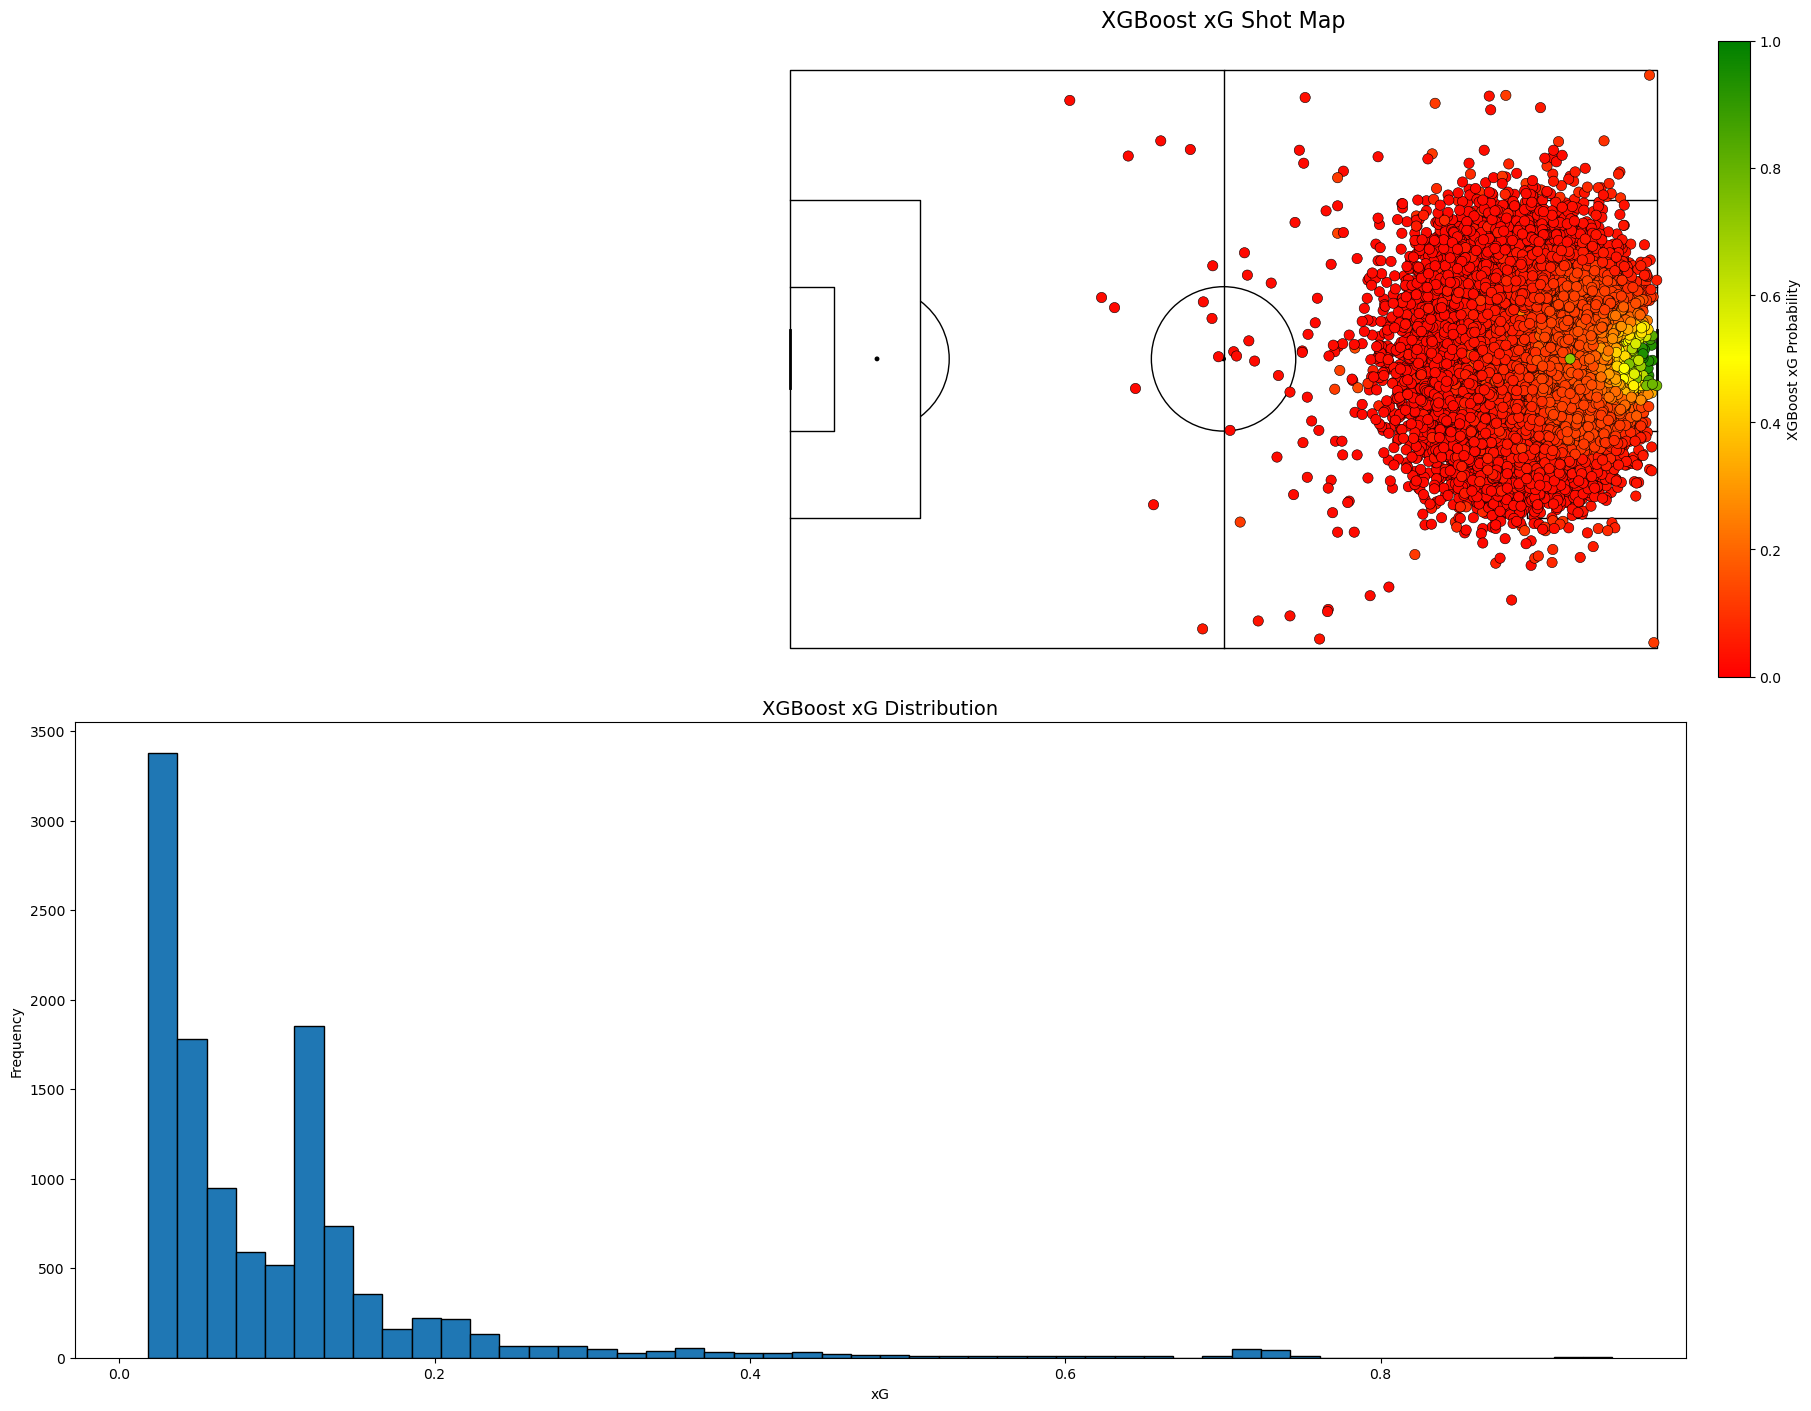

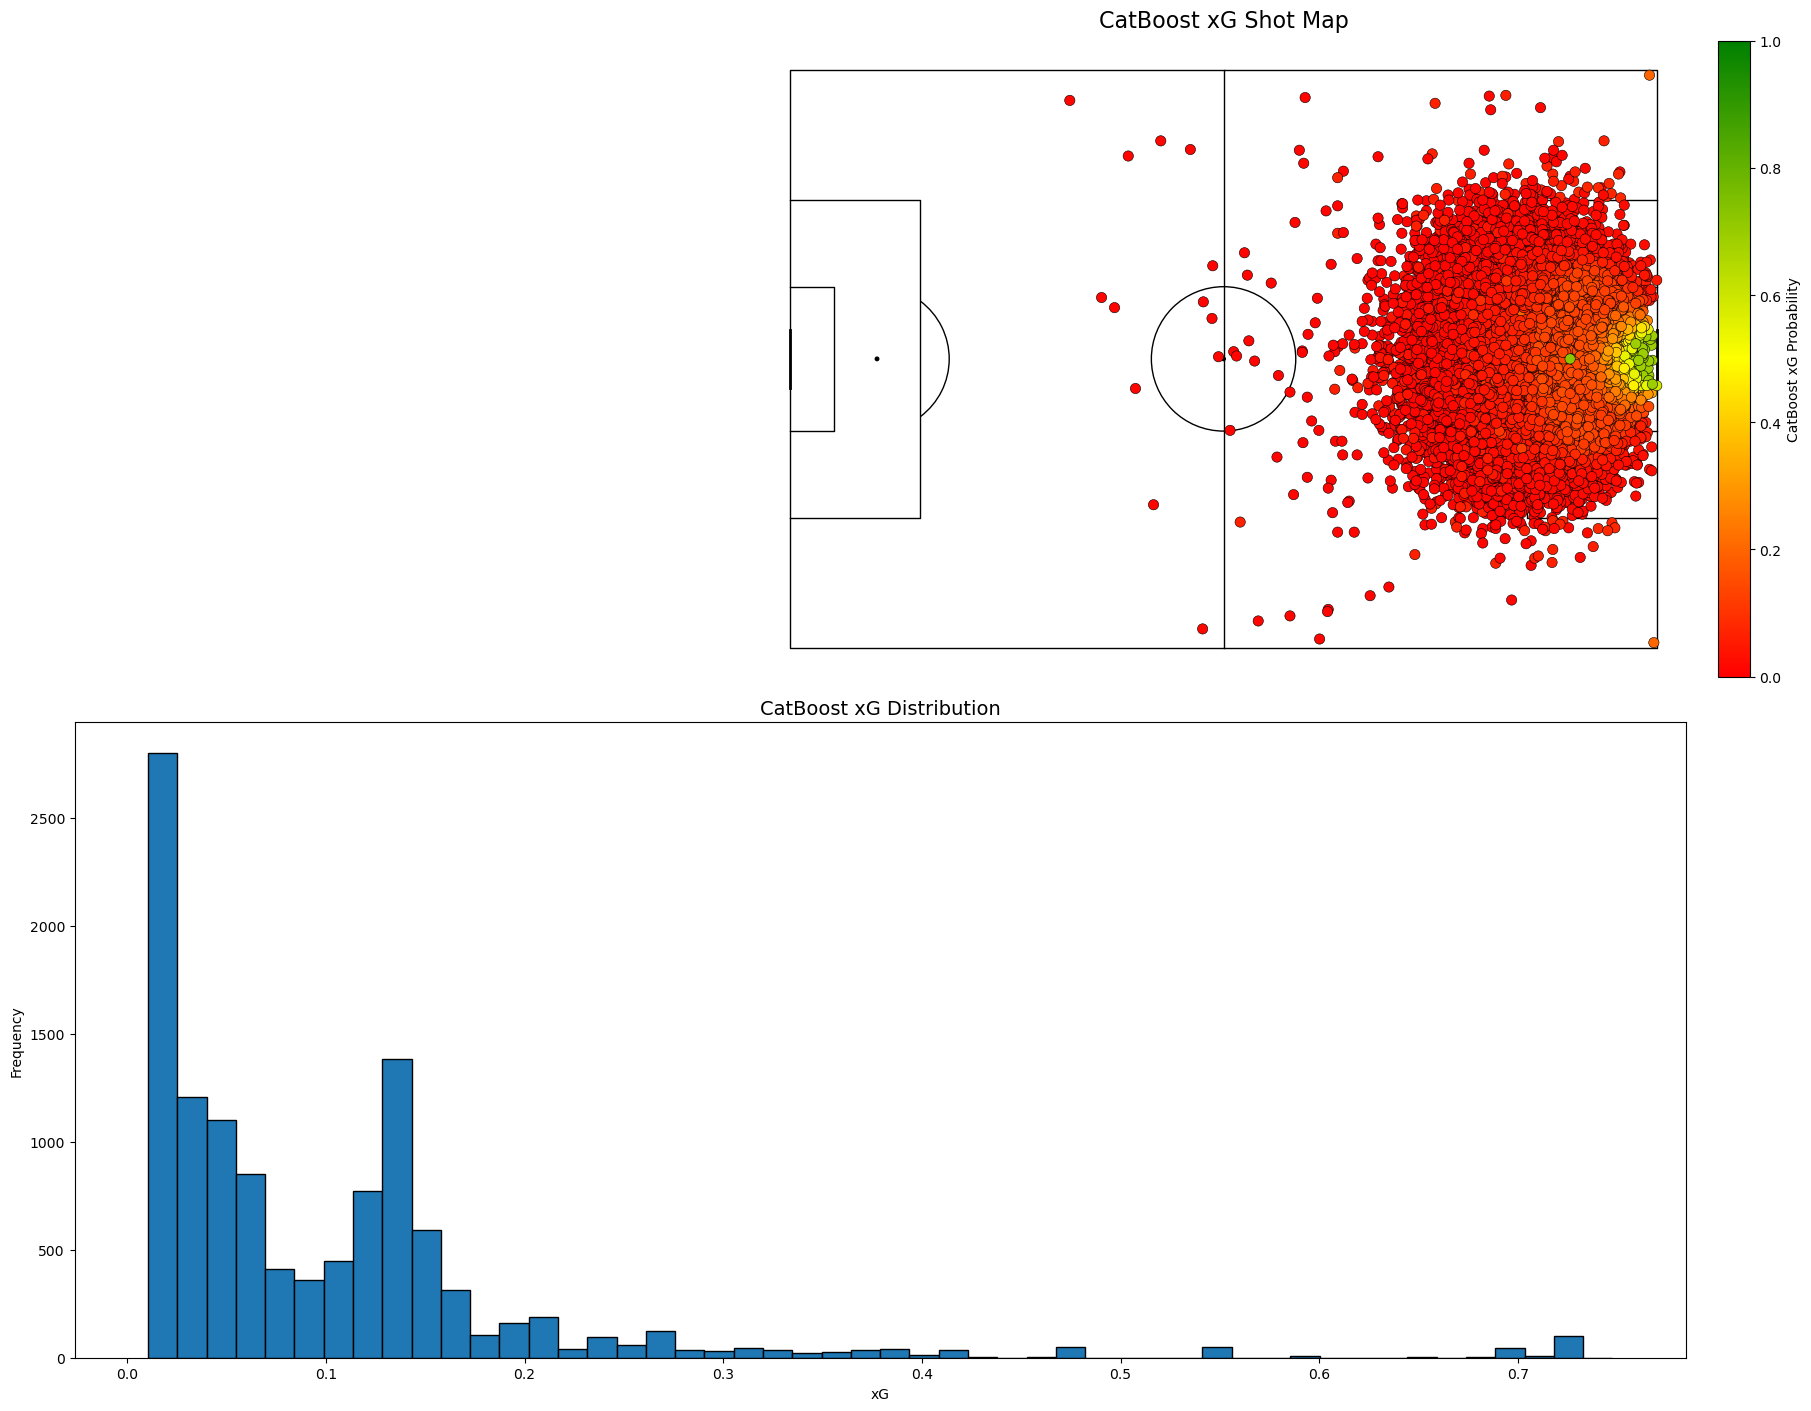

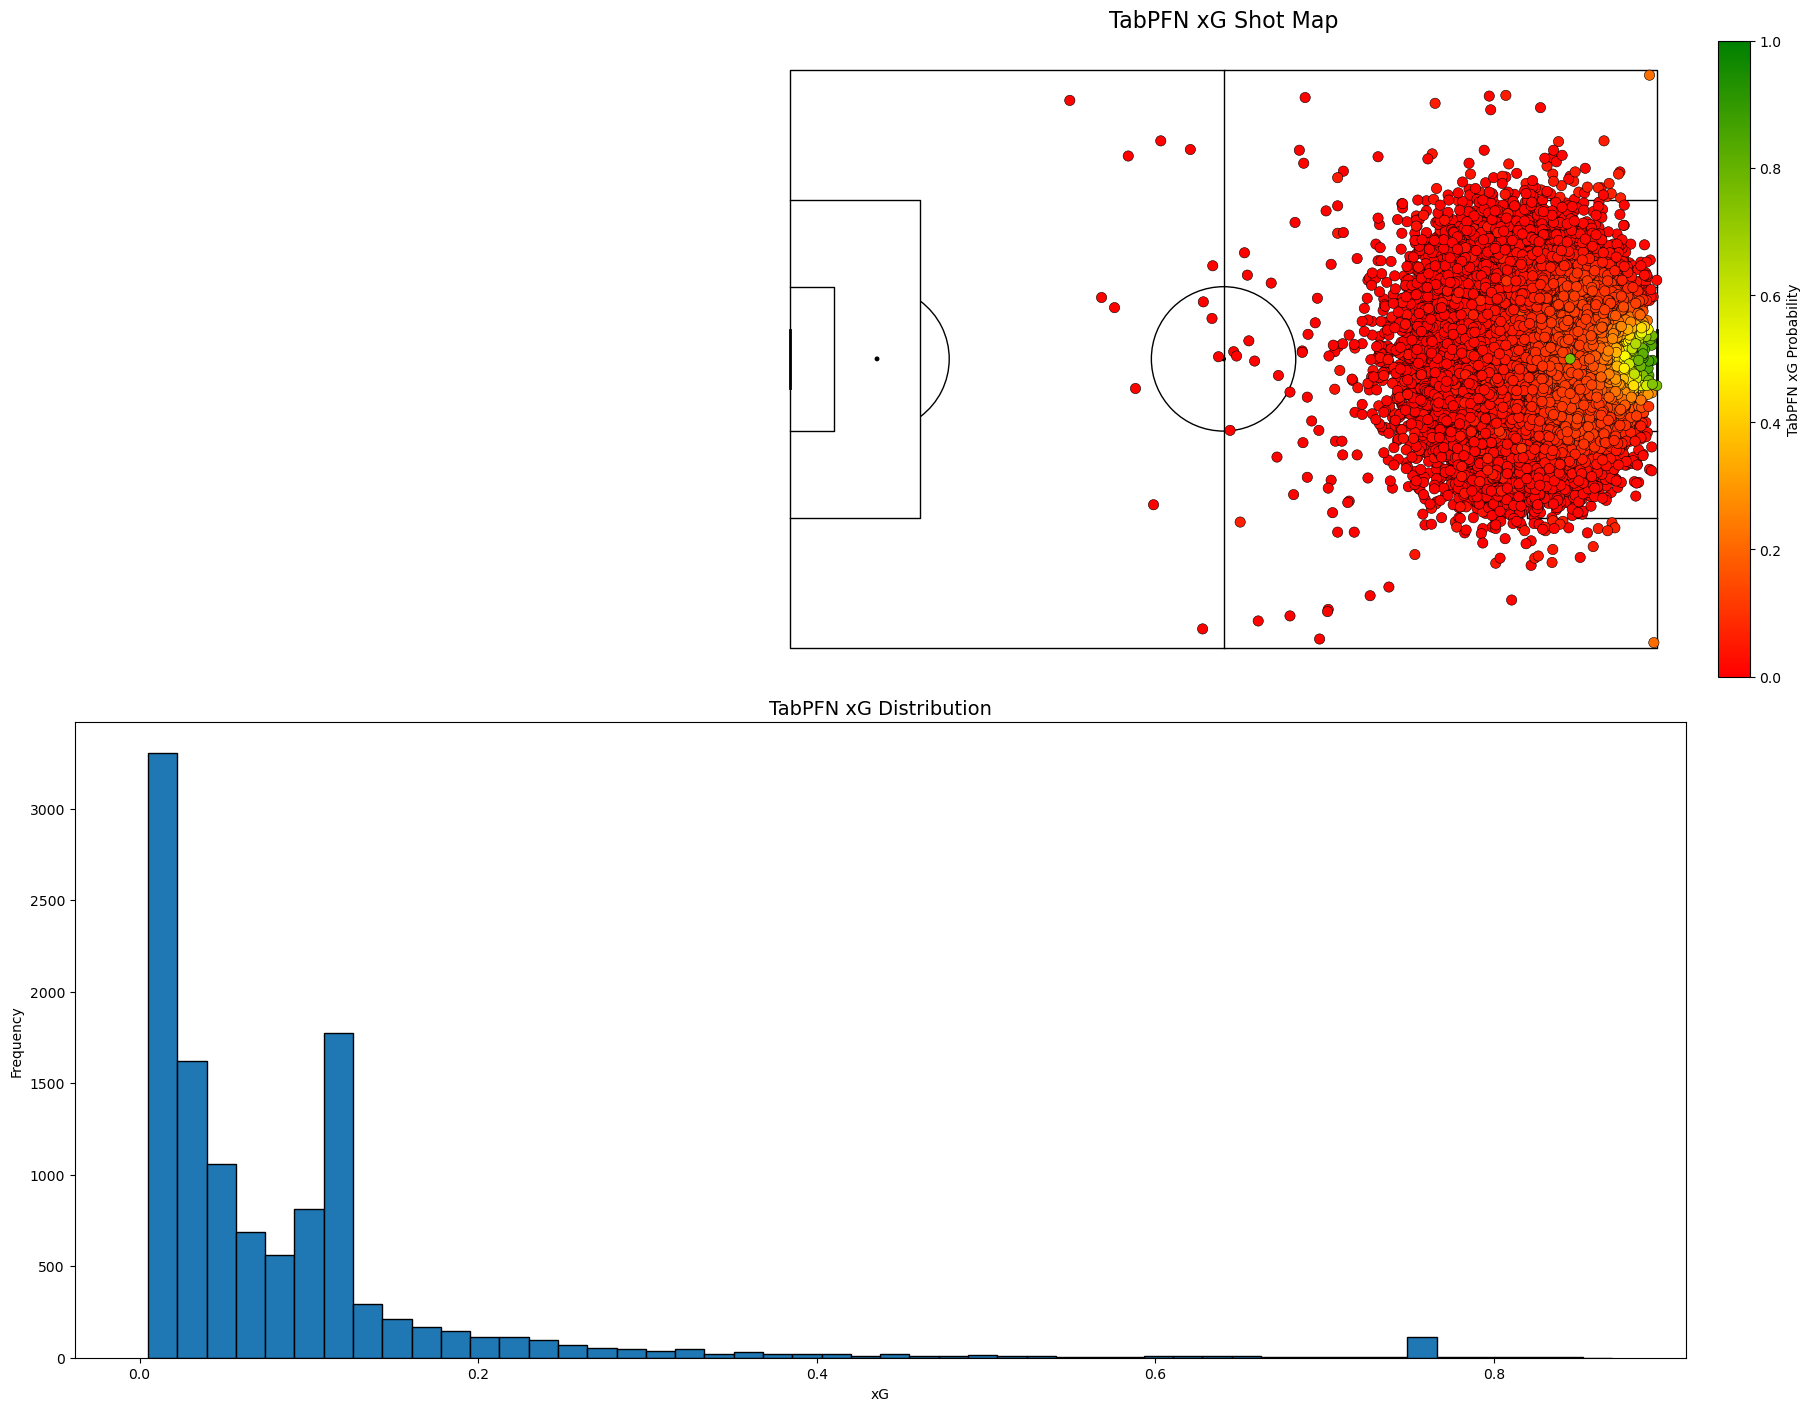

In [ ]:
import numpy as np
from matplotlib.gridspec import GridSpec

dataframes = {'Logistic Regression': log_df,
              'Random Forest': rf_df,
              'XGBoost': xgb_df,
              'CatBoost': cat_df,
              'TabPFN': tab_df}

for name, df in dataframes.items():
    fig = plt.figure(figsize=(18, 14), constrained_layout=True)
    gs = GridSpec(2, 1, height_ratios=[1, 1], figure=fig)

    ax_pitch = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1])

    # ---- TOP: Pitch Plot ----
    pitch.draw(ax=ax_pitch)

    sc = pitch.scatter(cordinates['x'], cordinates['y'], c=df['xG'], cmap=cmap,
                       edgecolors='black', linewidth=0.4, s=55, vmin=0, vmax=1, ax=ax_pitch)

    ax_pitch.set_title(f'{name} xG Shot Map', fontsize=16, pad=10)

    cbar = fig.colorbar(sc, ax=ax_pitch, fraction=0.025, pad=0.02)
    cbar.set_label(f'{name} xG Probability')

    # ---- BOTTOM: Histogram ----
    ax_hist.hist(df['xG'], bins=50, edgecolor='black')

    ax_hist.set_title(f'{name} xG Distribution', fontsize=14)
    ax_hist.set_xlabel('xG')
    ax_hist.set_ylabel('Frequency')

    plt.savefig(f'/Users/nanakwamekankam/Desktop/Football_Stats/xG/results/Baseline_Models/{name} xG Distribution')
    plt.show()